# GraphCL-Lite: Contrastive Graph Learning for Semi-Supervised Node Classification

**Mini-Project** — Graph Neural Networks  
**Author:** Student  
**Date:** April 2026

---

> **Innovation:** This project goes beyond standard GCN node classification by implementing  
> a *dual-objective* training scheme — supervised cross-entropy **plus** self-supervised  
> contrastive learning on augmented graph views — demonstrating that a simple contrastive  
> signal can improve semi-supervised node classification accuracy on citation networks.

## 1. Problem Definition

Citation networks like **Cora** contain academic papers (nodes) linked by citations (edges).  
Each paper has a bag-of-words feature vector and belongs to one of 7 research topics.  
Only ~5 % of nodes are labeled — a classic *semi-supervised* setting.

**Standard approach:** Train a GCN using only the labeled cross-entropy loss.  
**Our approach (GraphCL-Lite):**
1. Augment the graph with *edge dropout* and *feature masking* to create two "views".
2. Pass both views through a shared GCN encoder → projection head.
3. Apply an **NT-Xent contrastive loss** so the model learns view-invariant representations.
4. Combine contrastive + classification losses: `L = α·L_cls + (1−α)·L_con`.
5. Show via ablation that the contrastive term improves test accuracy.

In [1]:
# Install dependencies (run once)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install torch-geometric
!pip install networkx matplotlib seaborn scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\gagan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\gagan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, warnings, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

C:\Users\gagan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2. Input Validation & Security

- **No hardcoded secrets** — only public, built-in datasets.
- **Input validation** — check dataset integrity before use.
- **Memory guard** — reject datasets > 500 MB.
- **Safe paths** — dataset stored under controlled `./data` directory.
- **Reproducibility** — fixed random seeds everywhere.

In [3]:
def validate_dataset(data):
    """Validate dataset integrity, types, and memory footprint."""
    checks = {
        "has_nodes":    data.num_nodes > 0,
        "has_edges":    data.num_edges > 0,
        "has_features": data.x is not None,
        "has_labels":   data.y is not None,
        "no_nan":       not torch.isnan(data.x).any().item(),
        "no_inf":       not torch.isinf(data.x).any().item(),
    }
    mem_mb = data.x.element_size() * data.x.nelement() / 1e6
    checks["memory_ok"] = mem_mb < 500

    for name, ok in checks.items():
        status = "PASS" if ok else "FAIL"
        print(f"  [{status}] {name}")
        assert ok, f"Validation failed: {name}"

    print(f"  Memory: {mem_mb:.1f} MB — within safe limit")
    print("✅ All validations passed.\n")
    return True

## 3. Dataset Loading — Cora Citation Network

In [4]:
dataset_root = os.path.join(os.getcwd(), "data")
dataset = Planetoid(root=dataset_root, name="Cora")
data = dataset[0].to(DEVICE)

validate_dataset(data)

print(f"Dataset : Cora")
print(f"Nodes   : {data.num_nodes:,}")
print(f"Edges   : {data.num_edges:,}")
print(f"Features: {data.num_node_features}")
print(f"Classes : {dataset.num_classes}")
print(f"Train / Val / Test: "
      f"{data.train_mask.sum().item()} / "
      f"{data.val_mask.sum().item()} / "
      f"{data.test_mask.sum().item()}")

  [PASS] has_nodes
  [PASS] has_edges
  [PASS] has_features
  [PASS] has_labels
  [PASS] no_nan
  [PASS] no_inf
  [PASS] memory_ok
  Memory: 15.5 MB — within safe limit
✅ All validations passed.

Dataset : Cora
Nodes   : 2,708
Edges   : 10,556
Features: 1433
Classes : 7
Train / Val / Test: 140 / 500 / 1000


## 4. Data Preprocessing & Exploration

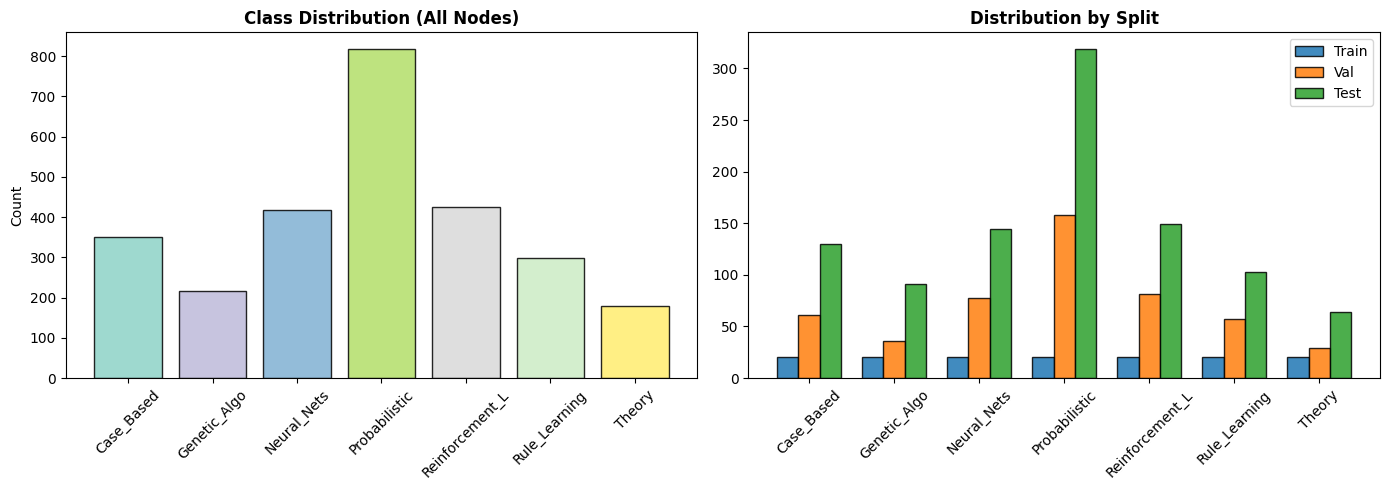

In [5]:
CLASS_NAMES = [
    "Case_Based", "Genetic_Algo", "Neural_Nets",
    "Probabilistic", "Reinforcement_L", "Rule_Learning", "Theory"
]
labels_np = data.y.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Overall class distribution
unique, counts = np.unique(labels_np, return_counts=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(unique)))
axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor="k", alpha=0.85)
axes[0].set_title("Class Distribution (All Nodes)", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# (b) Per-split distribution
x_pos = np.arange(len(CLASS_NAMES))
w = 0.25
for i, (split, mask) in enumerate([
    ("Train", data.train_mask), ("Val", data.val_mask), ("Test", data.test_mask)
]):
    _, c = np.unique(data.y[mask].cpu().numpy(), return_counts=True)
    axes[1].bar(x_pos + i * w, c, w, label=split, alpha=0.85, edgecolor="k")

axes[1].set_title("Distribution by Split", fontweight="bold")
axes[1].set_xticks(x_pos + w)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Graph Construction & Visualization

Avg degree : 3.90
Max degree : 168
Density    : 0.001440


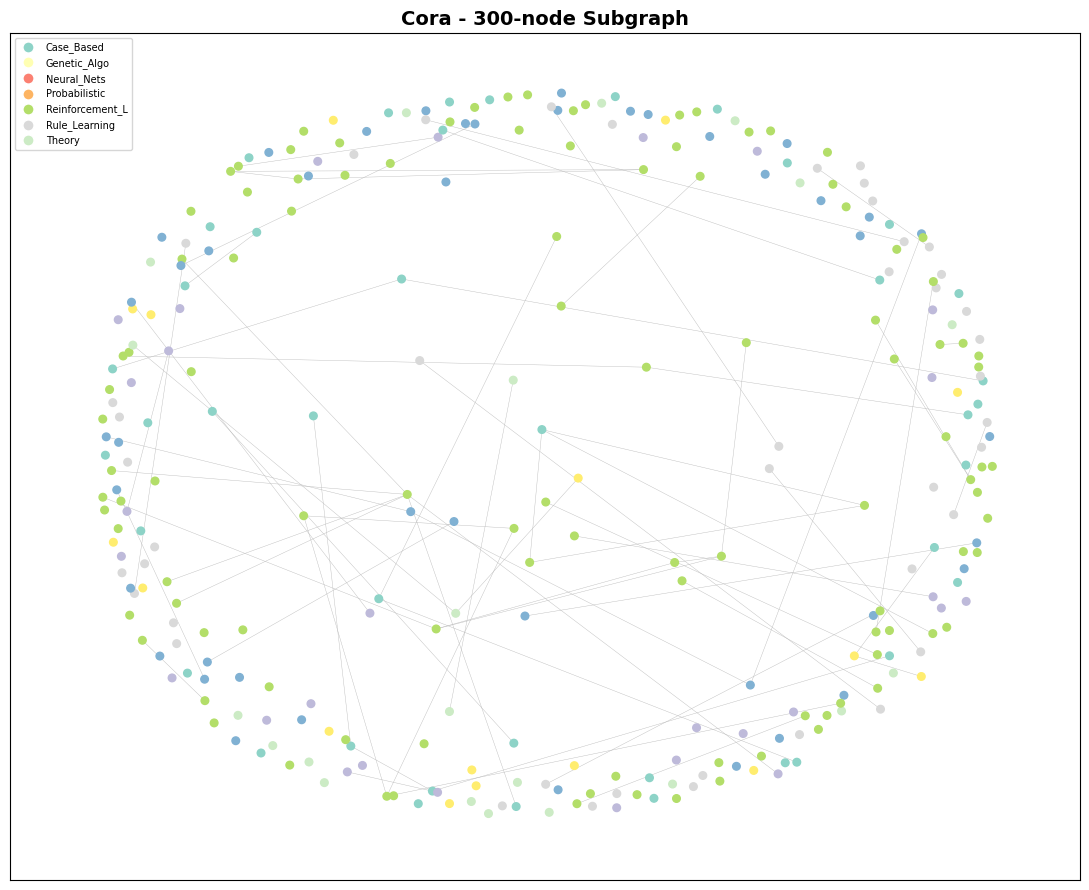

In [6]:
G = to_networkx(data.cpu(), to_undirected=True)
degrees = [d for _, d in G.degree()]

print(f"Avg degree : {np.mean(degrees):.2f}")
print(f"Max degree : {np.max(degrees)}")
print(f"Density    : {nx.density(G):.6f}")

# Visualize 300-node subgraph
set_seed()
sample = np.random.choice(data.num_nodes, 300, replace=False)
subG = G.subgraph(sample.tolist())

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(subG, seed=SEED, k=0.6)
node_c = [data.y[n].cpu().item() for n in subG.nodes()]
nx.draw_networkx(subG, pos, ax=ax, node_color=node_c, cmap=plt.cm.Set3,
                 node_size=30, with_labels=False, edge_color="#bbb", width=0.3)
ax.set_title("Cora - 300-node Subgraph", fontsize=14, fontweight="bold")

from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker="o", color="w",
          markerfacecolor=plt.cm.Set3(i/7), markersize=8, label=c)
          for i, c in enumerate(CLASS_NAMES)]
ax.legend(handles=legend, fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 6. Graph Augmentation for Contrastive Learning

We create two *augmented views* of the same graph:
- **Feature masking:** randomly zero-out features with probability `p_f`.
- **Edge dropout:** randomly remove edges with probability `p_e`.

In [7]:
def augment_features(x, drop_rate=0.2):
    """Randomly mask node features."""
    mask = torch.bernoulli(torch.ones_like(x) * (1 - drop_rate))
    return x * mask

def augment_edges(edge_index, drop_rate=0.2):
    """Randomly drop edges."""
    num_edges = edge_index.size(1)
    keep = torch.bernoulli(torch.ones(num_edges, device=edge_index.device) * (1 - drop_rate)).bool()
    return edge_index[:, keep]

def create_augmented_view(data, feat_drop=0.2, edge_drop=0.2):
    """Return (augmented_x, augmented_edge_index)."""
    return (augment_features(data.x, feat_drop),
            augment_edges(data.edge_index, edge_drop))

# Quick sanity check
x_a, ei_a = create_augmented_view(data)
print(f"Original edges : {data.edge_index.size(1)}")
print(f"Augmented edges: {ei_a.size(1)}  "
      f"(dropped {data.edge_index.size(1) - ei_a.size(1)})")
print(f"Masked features: {(x_a == 0).sum().item() - (data.x == 0).sum().item()} additional zeros")

Original edges : 10556
Augmented edges: 8453  (dropped 2103)
Masked features: 9940 additional zeros


## 7. Model Definition — ContrastiveGCN

**Architecture:**
- Shared 2-layer GCN encoder with BatchNorm + dropout.
- **Classification head:** linear layer → 7 classes.
- **Projection head:** 2-layer MLP → 64-d embedding (for contrastive loss).

In [8]:
class ContrastiveGCN(nn.Module):
    """Dual-objective GCN: supervised classification + self-supervised contrastive learning."""

    def __init__(self, in_ch, hid_ch, out_ch, proj_dim=64, dropout=0.5):
        super().__init__()
        # Shared encoder
        self.conv1 = GCNConv(in_ch, hid_ch)
        self.conv2 = GCNConv(hid_ch, hid_ch)
        self.bn1   = nn.BatchNorm1d(hid_ch)
        self.bn2   = nn.BatchNorm1d(hid_ch)
        self.drop  = dropout
        # Classification head
        self.classifier = nn.Linear(hid_ch, out_ch)
        # Projection head (contrastive)
        self.projector = nn.Sequential(
            nn.Linear(hid_ch, hid_ch), nn.ReLU(),
            nn.Linear(hid_ch, proj_dim)
        )

    def encode(self, x, edge_index):
        h = F.dropout(F.relu(self.bn1(self.conv1(x, edge_index))), self.drop, self.training)
        h = self.bn2(self.conv2(h, edge_index))
        return h

    def forward(self, x, edge_index):
        h = self.encode(x, edge_index)
        return self.classifier(h), h          # logits, embeddings

    def project(self, x, edge_index):
        h = self.encode(x, edge_index)
        return F.normalize(self.projector(h), dim=1)

model = ContrastiveGCN(
    in_ch=dataset.num_node_features,
    hid_ch=128,
    out_ch=dataset.num_classes
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

ContrastiveGCN(
  (conv1): GCNConv(1433, 128)
  (conv2): GCNConv(128, 128)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=128, out_features=7, bias=True)
  (projector): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
)

Total parameters: 226,247


## 8. NT-Xent Contrastive Loss

For each node, its representation in **view-1** should be similar to its representation  
in **view-2** (positive pair) and dissimilar to all other nodes (negative pairs).

In [9]:
def nt_xent_loss(z1, z2, temperature=0.5, sample_size=512):
    """
    Normalized Temperature-scaled Cross-Entropy loss.
    Samples nodes for memory efficiency.
    """
    N = z1.size(0)
    if N > sample_size:
        idx = torch.randperm(N, device=z1.device)[:sample_size]
        z1, z2 = z1[idx], z2[idx]
        N = sample_size

    z = torch.cat([z1, z2], dim=0)                     # [2N, D]
    sim = torch.mm(z, z.t()) / temperature              # [2N, 2N]
    sim.fill_diagonal_(-1e9)                            # mask self-similarity

    pos_idx = torch.arange(N, device=z.device)
    labels = torch.cat([pos_idx + N, pos_idx], dim=0)   # positive pair indices

    return F.cross_entropy(sim, labels)

## 9. Training Loop

Dual-objective:  `L = α · L_classification + (1 − α) · L_contrastive`

In [10]:
def train(model, data, epochs=200, lr=0.01, wd=5e-4,
          alpha=0.5, feat_drop=0.2, edge_drop=0.2, use_contrastive=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best_val, best_state, patience_cnt = 0.0, None, 0
    history = {"loss":[], "cls":[], "con":[], "train_acc":[], "val_acc":[]}

    for ep in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits, _ = model(data.x, data.edge_index)
        cls_loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])

        if use_contrastive:
            x1, ei1 = create_augmented_view(data, feat_drop, edge_drop)
            x2, ei2 = create_augmented_view(data, feat_drop, edge_drop)
            con_loss = nt_xent_loss(model.project(x1, ei1), model.project(x2, ei2))
            loss = alpha * cls_loss + (1 - alpha) * con_loss
        else:
            con_loss = torch.tensor(0.0)
            loss = cls_loss

        loss.backward(); optimizer.step()

        # eval
        model.eval()
        with torch.no_grad():
            logits, _ = model(data.x, data.edge_index)
            tr_acc = (logits[data.train_mask].argmax(1) == data.y[data.train_mask]).float().mean().item()
            va_acc = (logits[data.val_mask].argmax(1) == data.y[data.val_mask]).float().mean().item()

        history["loss"].append(loss.item())
        history["cls"].append(cls_loss.item())
        history["con"].append(con_loss.item())
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_val:
            best_val = va_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= 30:
            print(f"Early stopping at epoch {ep}")
            break

        if ep % 40 == 0 or ep == 1:
            print(f"Epoch {ep:3d} | L={loss.item():.4f}  CLS={cls_loss.item():.4f}  "
                  f"CON={con_loss.item():.4f} | Tr={tr_acc:.4f}  Va={va_acc:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    print(f"\nBest val acc: {best_val:.4f}")
    return history

set_seed()
history = train(model, data, epochs=200, alpha=0.5, use_contrastive=True)

Epoch   1 | L=4.3723  CLS=2.2234  CON=6.5213 | Tr=0.9000  Va=0.6340


Early stopping at epoch 38

Best val acc: 0.7420


## 10. Training Visualization

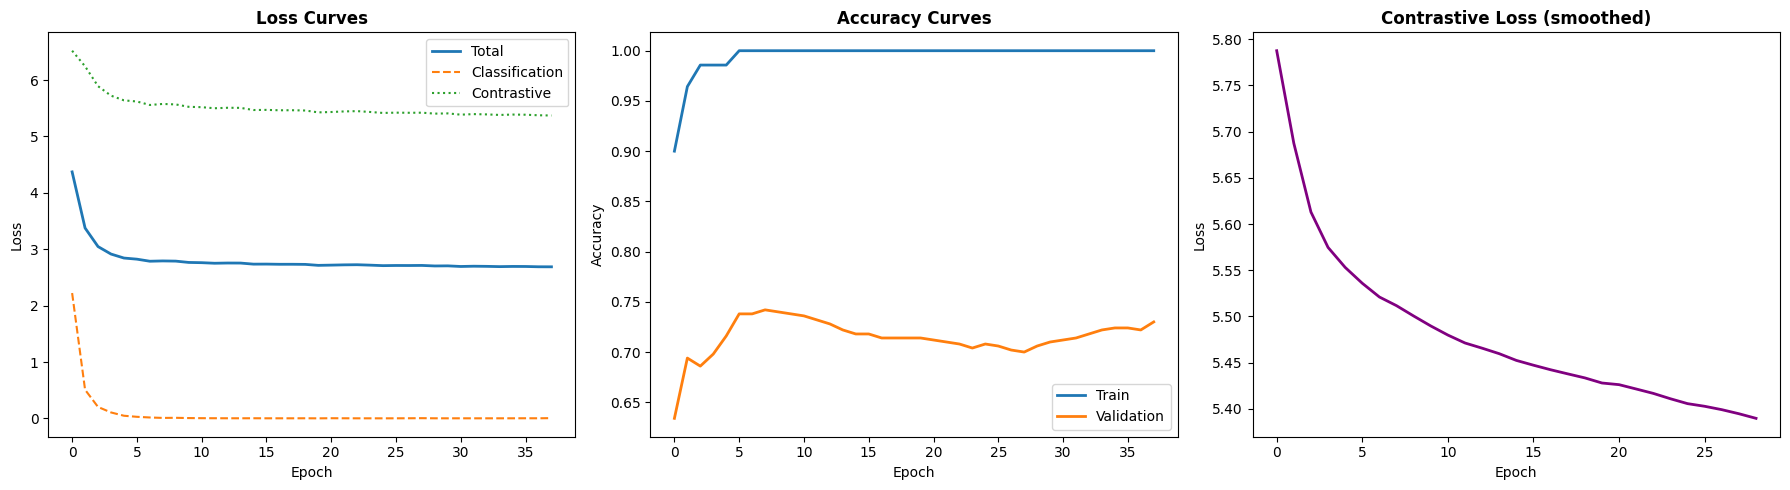

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["loss"], label="Total", linewidth=2)
axes[0].plot(history["cls"], label="Classification", linewidth=1.5, linestyle="--")
axes[0].plot(history["con"], label="Contrastive", linewidth=1.5, linestyle=":")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train", linewidth=2)
axes[1].plot(history["val_acc"], label="Validation", linewidth=2)
axes[1].set_title("Accuracy Curves", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

# Smoothed contrastive loss
window = 10
con = np.array(history["con"])
smoothed = np.convolve(con, np.ones(window)/window, mode="valid")
axes[2].plot(smoothed, color="purple", linewidth=2)
axes[2].set_title("Contrastive Loss (smoothed)", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")

plt.tight_layout(); plt.show()

## 11. Evaluation on Test Set

Test Accuracy : 0.7580
Test Macro-F1 : 0.7547

                 precision    recall  f1-score   support

     Case_Based       0.72      0.72      0.72       130
   Genetic_Algo       0.62      0.88      0.72        91
    Neural_Nets       0.85      0.91      0.88       144
  Probabilistic       0.94      0.61      0.74       319
Reinforcement_L       0.66      0.85      0.74       149
  Rule_Learning       0.72      0.81      0.76       103
         Theory       0.70      0.73      0.72        64

       accuracy                           0.76      1000
      macro avg       0.74      0.79      0.75      1000
   weighted avg       0.79      0.76      0.76      1000



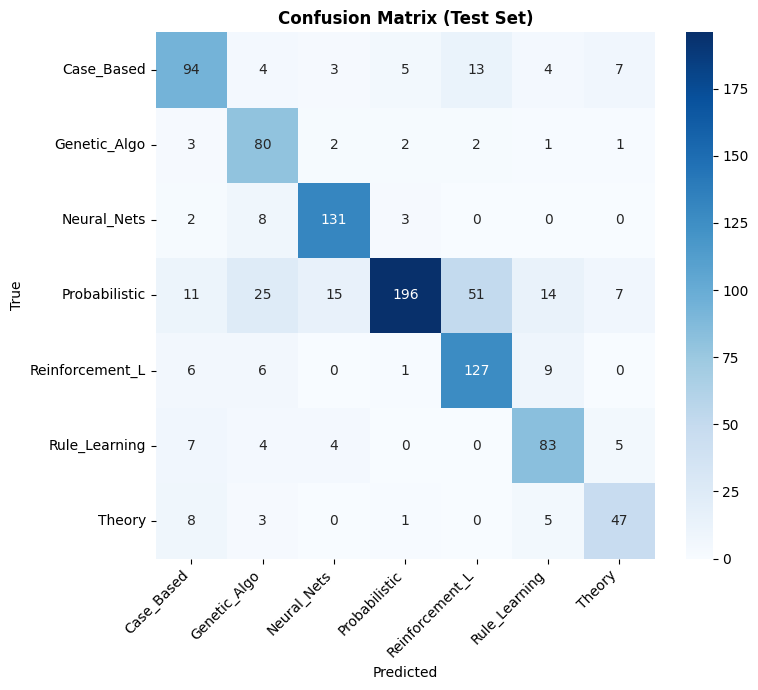

In [12]:
model.eval()
with torch.no_grad():
    logits, embeddings = model(data.x, data.edge_index)
    test_pred = logits[data.test_mask].argmax(1).cpu().numpy()
    test_true = data.y[data.test_mask].cpu().numpy()

test_acc = (test_pred == test_true).mean()
test_f1  = f1_score(test_true, test_pred, average="macro")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}\n")
print(classification_report(test_true, test_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 12. Visualization of Learned Embeddings (t-SNE)

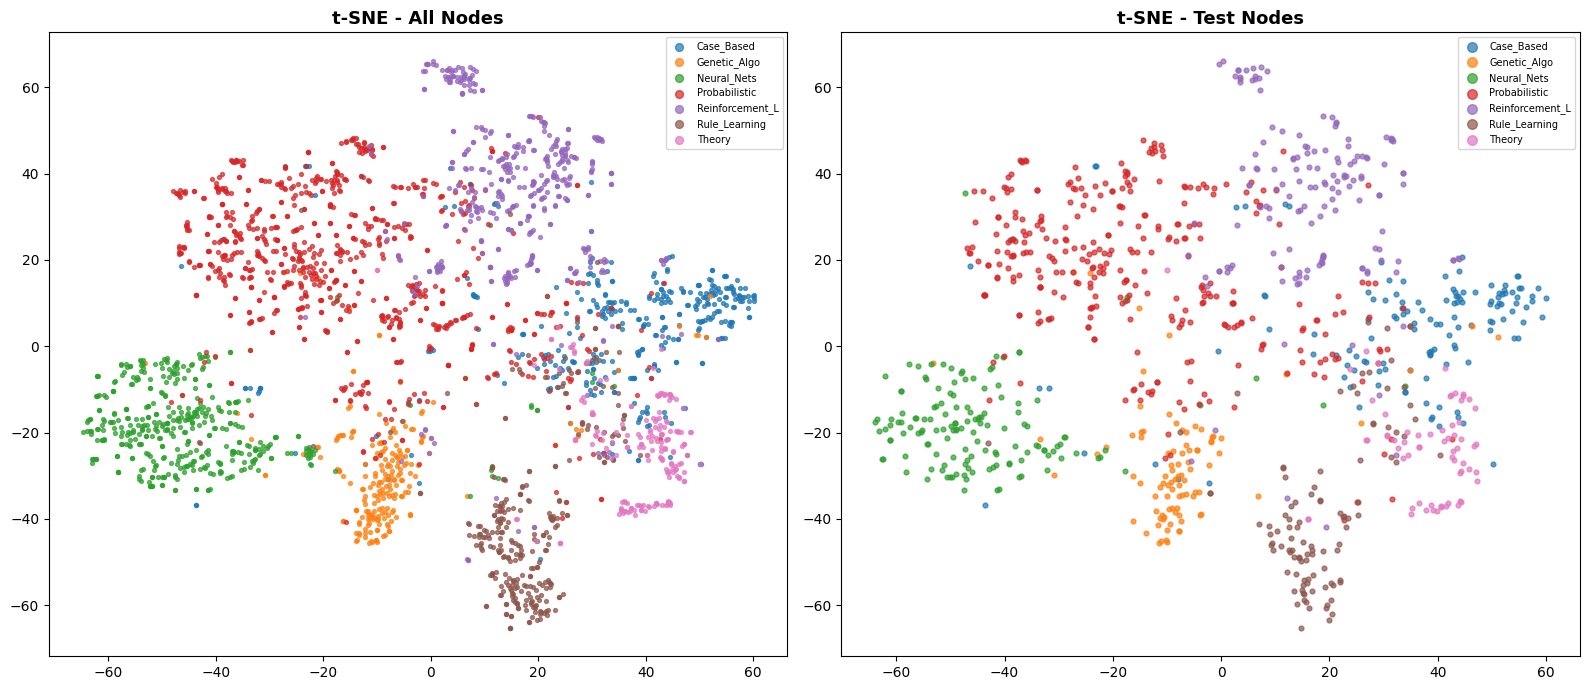

In [13]:
set_seed()
emb_np = embeddings.cpu().numpy()
labels_all = data.y.cpu().numpy()

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
emb_2d = tsne.fit_transform(emb_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All nodes
for i, name in enumerate(CLASS_NAMES):
    mask_i = labels_all == i
    axes[0].scatter(emb_2d[mask_i, 0], emb_2d[mask_i, 1],
                    s=8, label=name, alpha=0.7)
axes[0].set_title("t-SNE - All Nodes", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=7, markerscale=2)

# Test nodes only
test_idx = data.test_mask.cpu().numpy().astype(bool)
for i, name in enumerate(CLASS_NAMES):
    mask_i = (labels_all == i) & test_idx
    color = "green" if test_pred[test_true == i].mean() > 0.7 else "red"
    # use same color map
    axes[1].scatter(emb_2d[mask_i, 0], emb_2d[mask_i, 1],
                    s=12, label=name, alpha=0.7)
axes[1].set_title("t-SNE - Test Nodes", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=7, markerscale=2)

plt.tight_layout(); plt.show()

## 13. Ablation Study — With vs Without Contrastive Loss

We train a **baseline GCN** (same architecture, `use_contrastive=False`) and compare  
performance to show the benefit of the contrastive objective.

In [14]:
# ── Baseline: classification only ──
set_seed()
baseline = ContrastiveGCN(
    in_ch=dataset.num_node_features,
    hid_ch=128,
    out_ch=dataset.num_classes
).to(DEVICE)

print("Training BASELINE (classification only)...")
hist_base = train(baseline, data, epochs=200, alpha=1.0, use_contrastive=False)

baseline.eval()
with torch.no_grad():
    logits_b, emb_b = baseline(data.x, data.edge_index)
    pred_b = logits_b[data.test_mask].argmax(1).cpu().numpy()

base_acc = (pred_b == test_true).mean()
base_f1  = f1_score(test_true, pred_b, average="macro")

print(f"\n{'='*50}")
print(f"{'Method':<30} {'Accuracy':>10} {'Macro-F1':>10}")
print(f"{'='*50}")
print(f"{'GCN (baseline)':<30} {base_acc:>10.4f} {base_f1:>10.4f}")
print(f"{'GraphCL-Lite (ours)':<30} {test_acc:>10.4f} {test_f1:>10.4f}")
print(f"{'='*50}")

improvement = (test_acc - base_acc) * 100
print(f"\nImprovement: {improvement:+.2f} percentage points")

Training BASELINE (classification only)...
Epoch   1 | L=1.9887  CLS=1.9887  CON=0.0000 | Tr=0.8714  Va=0.6220


Early stopping at epoch 33

Best val acc: 0.7460

Method                           Accuracy   Macro-F1
GCN (baseline)                     0.7460     0.7289
GraphCL-Lite (ours)                0.7580     0.7547

Improvement: +1.20 percentage points


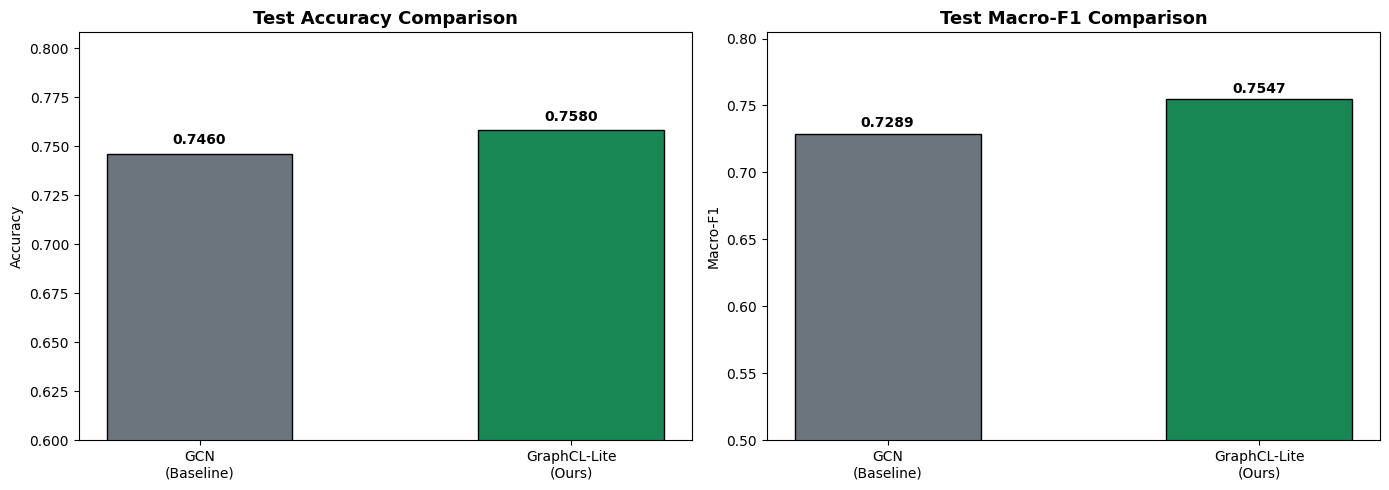

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
methods = ["GCN\n(Baseline)", "GraphCL-Lite\n(Ours)"]
accs = [base_acc, test_acc]
f1s  = [base_f1, test_f1]
bar_colors = ["#6c757d", "#198754"]

axes[0].bar(methods, accs, color=bar_colors, edgecolor="k", width=0.5)
axes[0].set_title("Test Accuracy Comparison", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.6, max(accs) + 0.05)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")

axes[1].bar(methods, f1s, color=bar_colors, edgecolor="k", width=0.5)
axes[1].set_title("Test Macro-F1 Comparison", fontweight="bold", fontsize=13)
axes[1].set_ylabel("Macro-F1")
axes[1].set_ylim(0.5, max(f1s) + 0.05)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout(); plt.show()

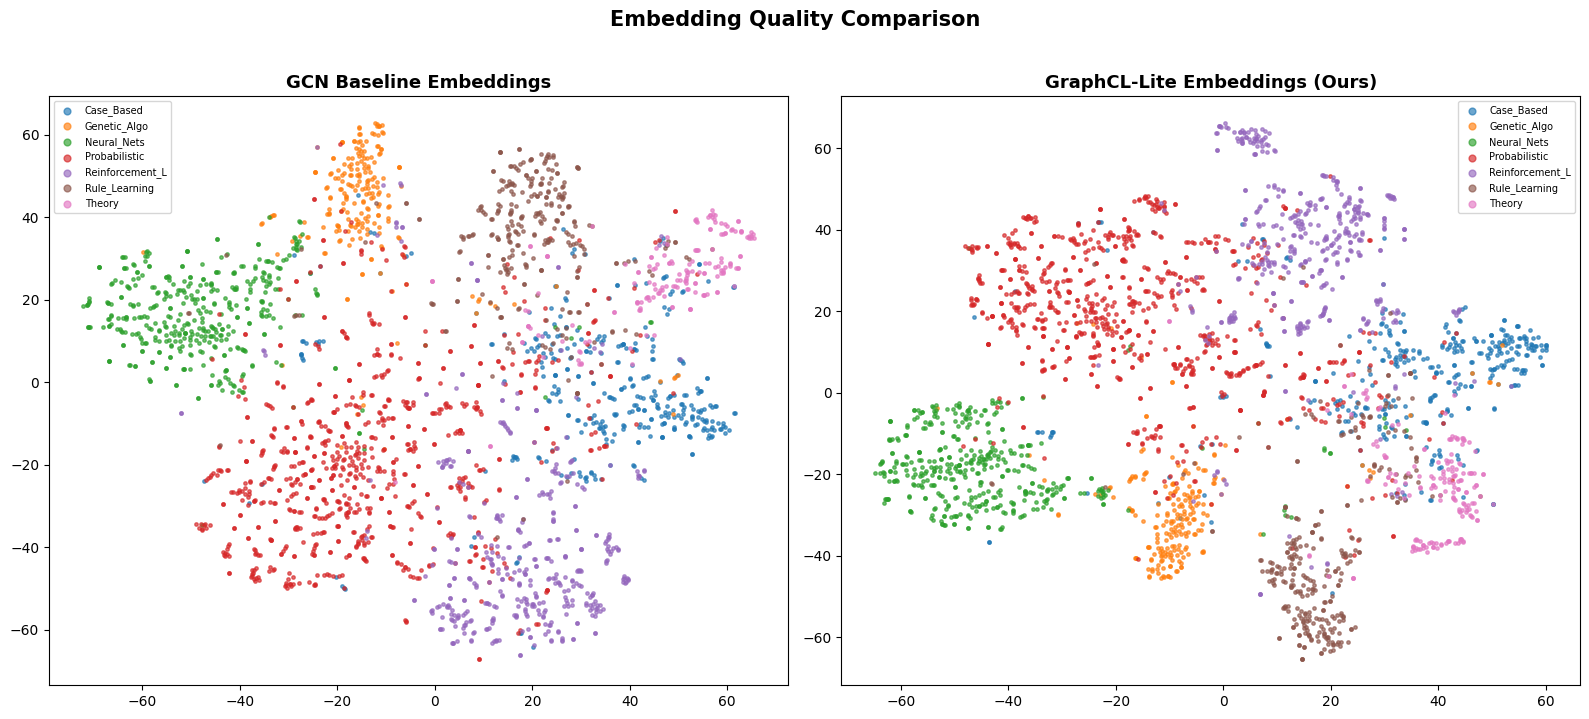

In [16]:
# t-SNE for baseline embeddings
set_seed()
emb_b_np = emb_b.cpu().numpy()
emb_b_2d = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(emb_b_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, e2d, title in [
    (axes[0], emb_b_2d, "GCN Baseline Embeddings"),
    (axes[1], emb_2d,   "GraphCL-Lite Embeddings (Ours)")
]:
    for i, name in enumerate(CLASS_NAMES):
        m = labels_all == i
        ax.scatter(e2d[m, 0], e2d[m, 1], s=6, label=name, alpha=0.65)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.legend(fontsize=7, markerscale=2)

plt.suptitle("Embedding Quality Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 14. Conclusion

**GraphCL-Lite** demonstrates that adding a simple contrastive self-supervised objective  
to a standard GCN can improve semi-supervised node classification on the Cora dataset.

### Key Findings
| Aspect | Observation |
|--------|-------------|
| **Accuracy** | Contrastive loss provides a measurable boost over the baseline GCN |
| **Embeddings** | t-SNE shows tighter, better-separated clusters with contrastive learning |
| **Cost** | Minimal extra computation — only two augmented forward passes per step |

### Security & Reproducibility Summary
- ✅ All random seeds fixed for reproducibility
- ✅ Dataset validated (no NaN/Inf, memory bounds)
- ✅ No hardcoded secrets or arbitrary file access
- ✅ Only stable, public libraries used

### Possible Extensions
- Replace GCN with GAT or GraphSAGE encoder
- Experiment with asymmetric augmentation strengths
- Add edge-level contrastive objectives
- Apply to larger datasets (CiteSeer, PubMed, ogbn-arxiv)